<a href="https://colab.research.google.com/github/princeprasad456/Diabetes-Prediction-Model/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================
# STEP 1: Import Libraries
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# =========================
# STEP 2: Load Dataset
# =========================

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
data = pd.read_csv(url)

print("Dataset loaded successfully.")
display(data.head())

# Conclusion:
# The dataset contains medical information such as glucose level, blood pressure,
# BMI, insulin, age, and diabetes outcome.
# Outcome = 1 means the person has diabetes.
# Outcome = 0 means the person does not have diabetes.

Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# =========================
# STEP 3: Basic EDA
# =========================

print("Dataset Shape:", data.shape)

print("\nDataset Information:")
data.info()

print("\nStatistical Summary:")
display(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Variable Distribution:")
print(data["Outcome"].value_counts())

# Conclusion:
# This step helps us understand the dataset size, data types, missing values,
# and basic statistics.
# There are no direct missing values, but some columns have zero values that are
# medically unrealistic, such as Glucose, BloodPressure, Insulin, and BMI.

Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


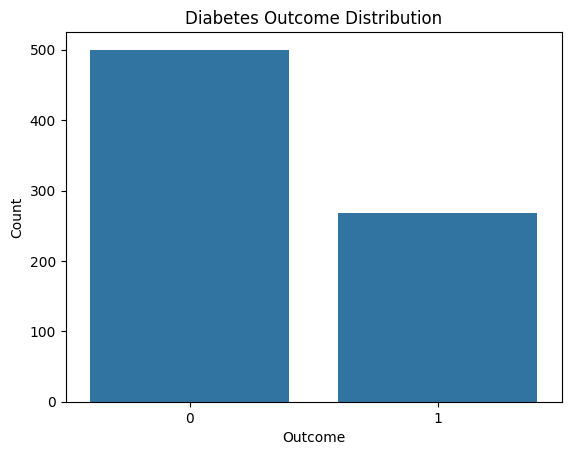

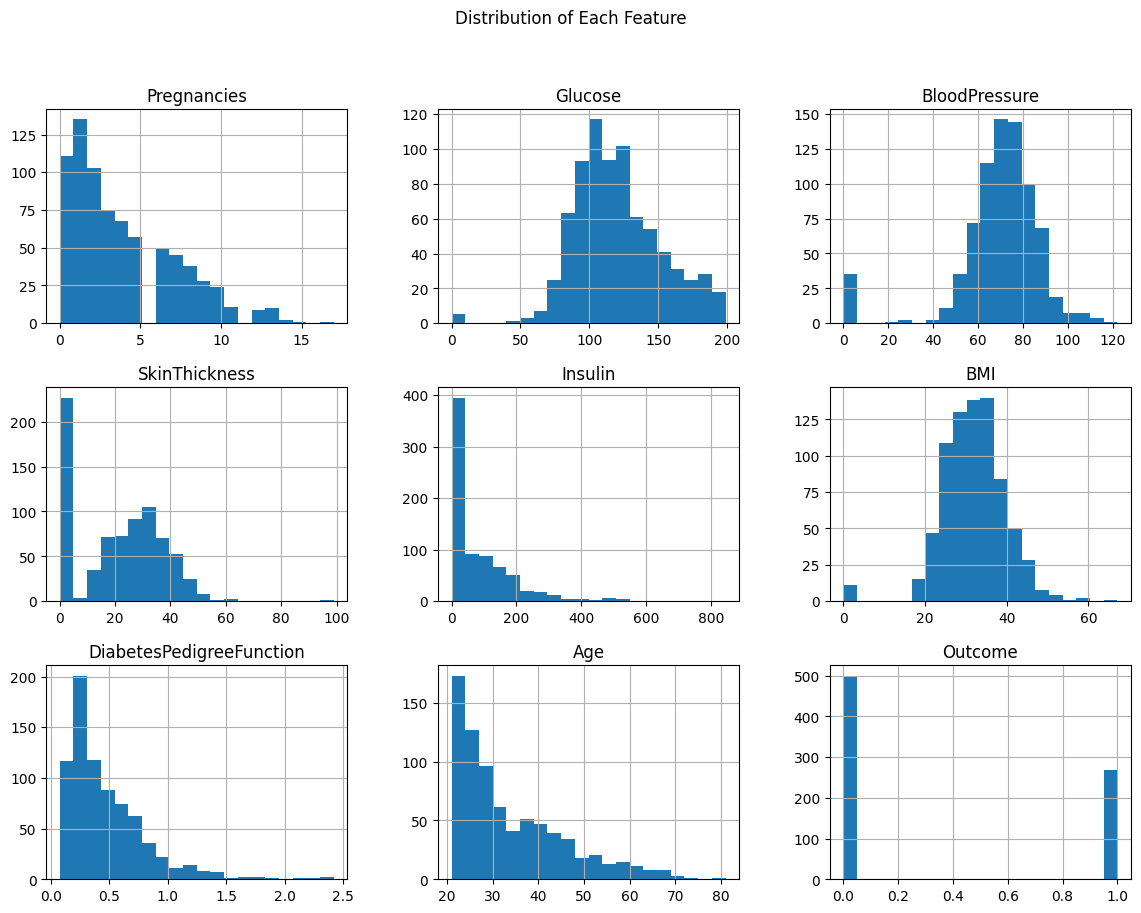

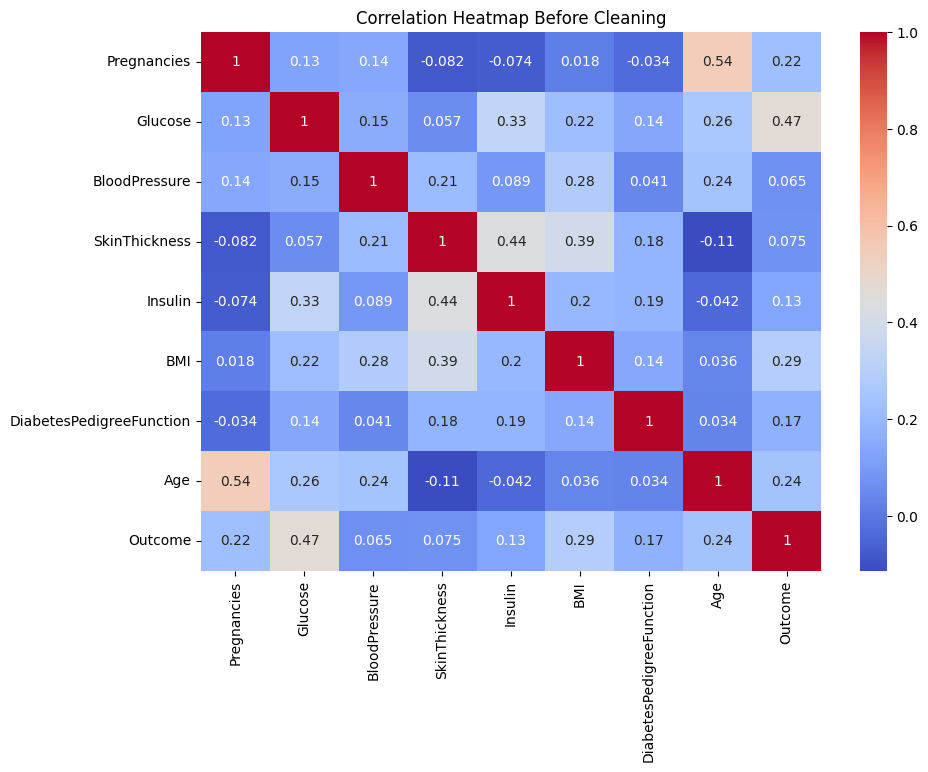

In [5]:
# =========================
# STEP 4: Visual EDA With Graph Conclusions
# =========================

sns.countplot(x="Outcome", data=data)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

# Conclusion:
# The graph shows that non-diabetic cases are more than diabetic cases.
# This means the dataset is slightly imbalanced.

data.hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribution of Each Feature")
plt.show()

# Conclusion:
# The histograms show how each feature is distributed.
# Some features like Insulin and SkinThickness contain many zero values,
# which indicates that data cleaning is required.

plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap Before Cleaning")
plt.show()

# Conclusion:
# Glucose has the strongest positive correlation with diabetes outcome.
# BMI, Age, and Pregnancies also show some relationship with diabetes.


In [6]:
# =========================
# STEP 5: Data Cleaning
# =========================

# Found 0 in some column of dataset which is practically not possible

zero_not_allowed = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_not_allowed:
    data[column] = data[column].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(data.isnull().sum())

for column in zero_not_allowed:
    data[column] = data[column].fillna(data[column].median())

print("\nMissing values after filling with median:")
print(data.isnull().sum())

# Conclusion:
# Zero values in important medical columns were treated as missing values.
# These missing values were filled using the median because median is less
# affected by outliers compared to mean.

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after filling with median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Category,Glucose_BMI,Age_BMI
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,3,2,2,4972.8,1680.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2,1,0,2261.0,824.6
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1,1,2,4263.9,745.6
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2,0,0,2500.9,590.1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,3,1,2,5904.7,1422.3


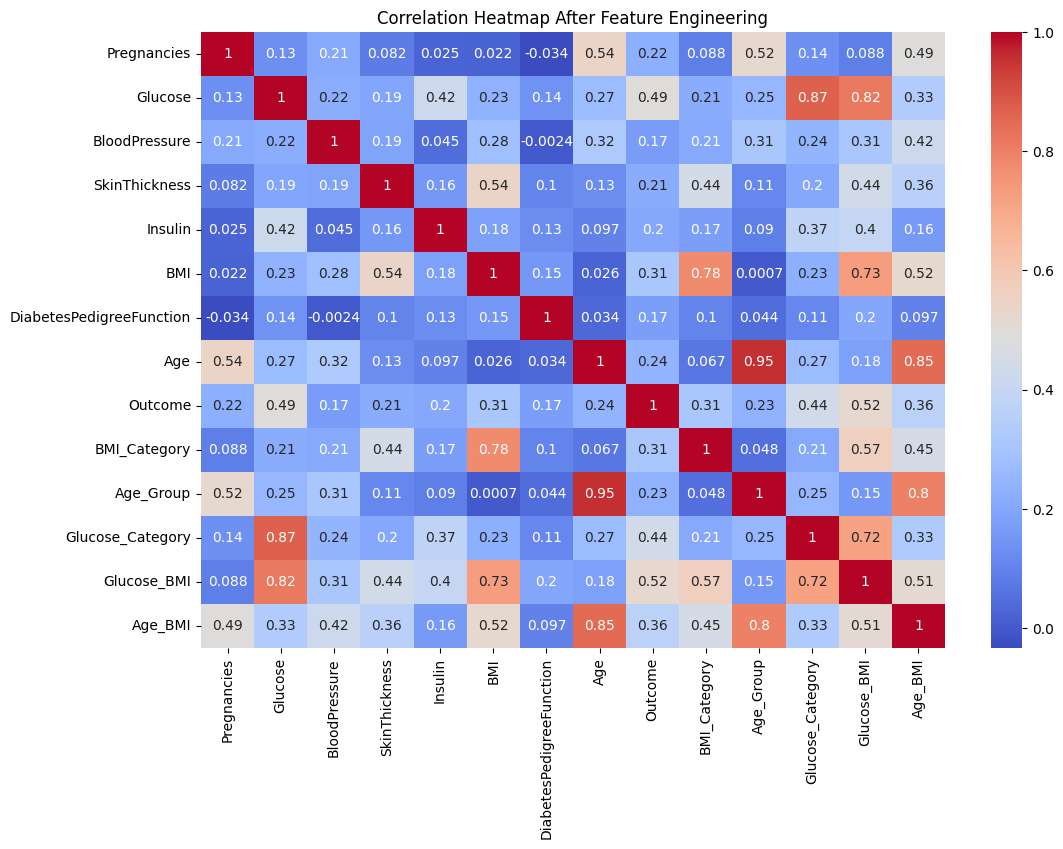

In [7]:
# =========================
# STEP 6: Feature Engineering
# =========================

def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

def age_group(age):
    if age < 30:
        return 0
    elif age < 45:
        return 1
    elif age < 60:
        return 2
    else:
        return 3

def glucose_category(glucose):
    if glucose < 100:
        return 0
    elif glucose < 126:
        return 1
    else:
        return 2

data["BMI_Category"] = data["BMI"].apply(bmi_category)
data["Age_Group"] = data["Age"].apply(age_group)
data["Glucose_Category"] = data["Glucose"].apply(glucose_category)

data["Glucose_BMI"] = data["Glucose"] * data["BMI"]
data["Age_BMI"] = data["Age"] * data["BMI"]

display(data.head())

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

# Conclusion:
# New features were created from existing medical values.
# BMI_Category, Age_Group, and Glucose_Category simplify continuous values.
# Glucose_BMI and Age_BMI help capture combined health effects.
# The new correlation heatmap helps us check whether these engineered features
# are useful for prediction.

In [8]:
# =========================
# STEP 7: Train-Test Split and Scaling
# =========================

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Conclusion:
# The dataset was divided into training and testing sets.
# 80% of the data is used for training and 20% is used for testing.
# Scaling is applied because Logistic Regression and PCA work better when
# features are on a similar scale.

Training data shape: (614, 13)
Testing data shape: (154, 13)


In [9]:
# =========================
# STEP 8: Model Training
# =========================

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

# Conclusion:
# Logistic Regression is used as a simple baseline model.
# Random Forest is used because it can capture complex relationships in the data.
# The accuracy scores show how well each model performs on unseen test data.

Logistic Regression Accuracy: 0.7077922077922078
Random Forest Accuracy: 0.7597402597402597


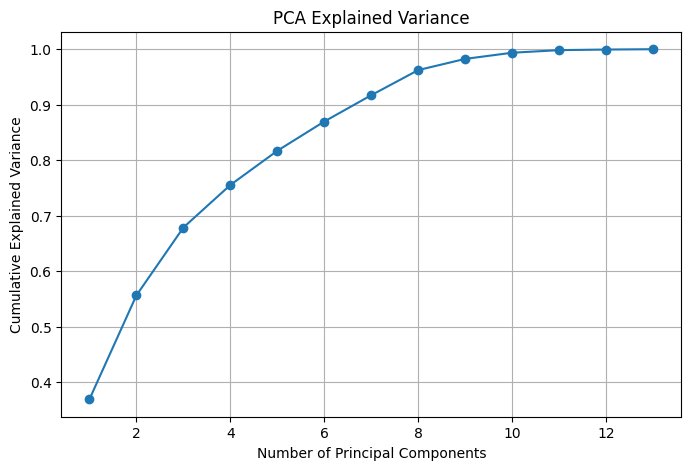

Number of PCA components selected: 8
Logistic Regression with PCA Accuracy: 0.7142857142857143


In [10]:
# =========================
# STEP 9: PCA Analysis
# =========================

pca = PCA()
pca.fit(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

pca_95 = PCA(n_components=0.95)

X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print("Number of PCA components selected:", pca_95.n_components_)

pca_logistic_model = LogisticRegression(max_iter=1000)
pca_logistic_model.fit(X_train_pca, y_train)

pca_pred = pca_logistic_model.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, pca_pred)

print("Logistic Regression with PCA Accuracy:", pca_accuracy)

# Conclusion:
# PCA is used to reduce the number of features while keeping most of the
# important information.
# The graph shows how much variance is retained as components increase.
# PCA is optional here because the dataset does not have too many features,
# but it is included to compare performance.

In [11]:
# =========================
# STEP 10: Model Comparison
# =========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression with PCA"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        pca_accuracy
    ]
})

display(results)

best_model_name = results.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = logistic_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = pca_logistic_model

# Conclusion:
# This step compares all trained models using accuracy.
# The model with the highest accuracy is selected as the final model.
# The graph makes it easy to visually compare model performance.

,Model,Accuracy
0,Logistic Regression,0.707792
1,Random Forest,0.759740
2,Logistic Regression with PCA,0.714286


Best Model: Random Forest


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



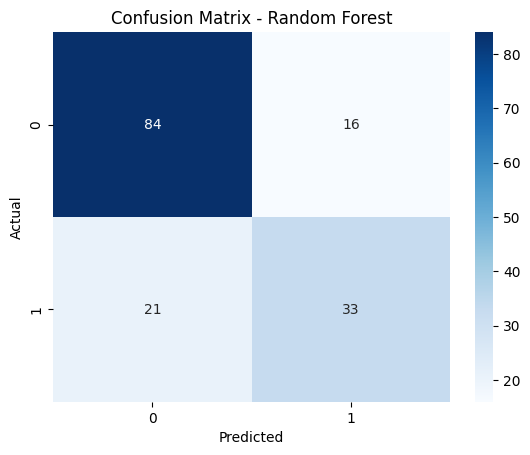

,Feature,Importance
1,Glucose,0.160217
11,Glucose_BMI,0.155445
12,Age_BMI,0.111180
5,BMI,0.092002
6,DiabetesPedigreeFunction,0.091983
7,Age,0.069484
10,Glucose_Category,0.059866
4,Insulin,0.056200
2,BloodPressure,0.055397
3,SkinThickness,0.050688


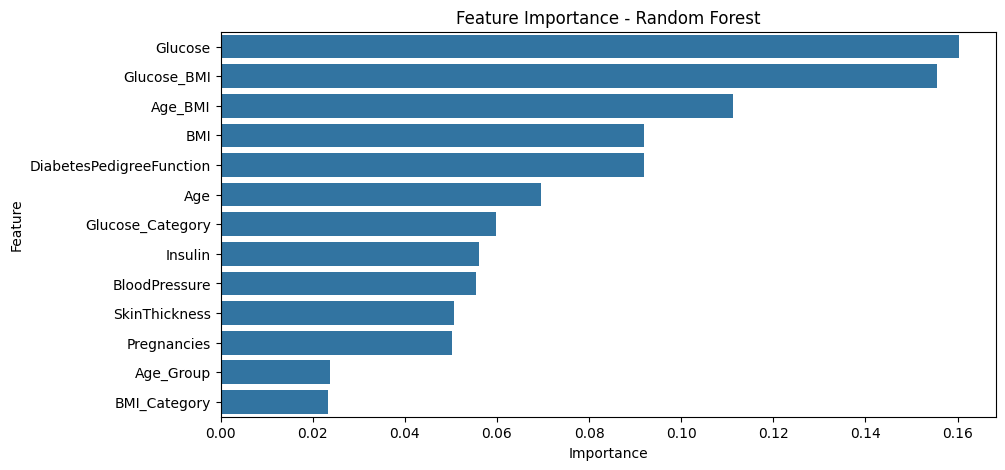

In [12]:
# =========================
# STEP 11 : Evaluation Graphs
# =========================

print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Conclusion:
# The confusion matrix shows correct and incorrect predictions.
# It helps us understand how many diabetic and non-diabetic cases were
# classified correctly.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

# Conclusion:
# The feature importance graph shows which features contributed most to prediction.
# Glucose-related features, BMI, and age-related features are usually important.
# This matches real medical understanding because blood sugar, body weight,
# and age are strongly related to diabetes risk.

In [13]:
# =========================
# STEP 12: Final Prediction Function and Conclusion
# =========================

def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree_function,
    age
):
    bmi_cat = bmi_category(bmi)
    age_grp = age_group(age)
    glucose_cat = glucose_category(glucose)

    glucose_bmi = glucose * bmi
    age_bmi = age * bmi

    input_data = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [blood_pressure],
        "SkinThickness": [skin_thickness],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [diabetes_pedigree_function],
        "Age": [age],
        "BMI_Category": [bmi_cat],
        "Age_Group": [age_grp],
        "Glucose_Category": [glucose_cat],
        "Glucose_BMI": [glucose_bmi],
        "Age_BMI": [age_bmi]
    })

    if best_model_name == "Random Forest":
        prediction = best_model.predict(input_data)
        probability = best_model.predict_proba(input_data)[0][1]

    elif best_model_name == "Logistic Regression":
        input_scaled = scaler.transform(input_data)
        prediction = best_model.predict(input_scaled)
        probability = best_model.predict_proba(input_scaled)[0][1]

    else:
        input_scaled = scaler.transform(input_data)
        input_pca = pca_95.transform(input_scaled)
        prediction = best_model.predict(input_pca)
        probability = best_model.predict_proba(input_pca)[0][1]

    print("Prediction Result:")

    if prediction[0] == 1:
        print("The person has a HIGH chance of diabetes.")
    else:
        print("The person has a LOW chance of diabetes.")

    print("Diabetes Probability:", round(probability * 100, 2), "%")


predict_diabetes(
    pregnancies=2,
    glucose=120,
    blood_pressure=70,
    skin_thickness=25,
    insulin=80,
    bmi=28.5,
    diabetes_pedigree_function=0.45,
    age=35
)

# Final Conclusion:
# In this project, we created a diabetes chance prediction model using machine learning.
# EDA helped us understand the dataset, distributions, correlations, and outliers.
# Data cleaning handled unrealistic zero values.
# Feature engineering created meaningful new features to improve learning.
# PCA was applied to check whether dimensionality reduction improves performance.
# Multiple models were trained and compared.
# The best-performing model was selected for final diabetes prediction.

Prediction Result:
The person has a LOW chance of diabetes.
Diabetes Probability: 45.0 %
